GLAUCOMA ML TRAINING

Dataset loaded successfully!

Dataset shape:
(5000, 10)

First 5 records:
  patient_id  age gender  iop_mmhg  vertical_cdr  rnfl_thickness_um  \
0      P0001   68      F     19.60          0.50               88.3   
1      P0002   81      F     21.36          0.43               94.1   
2      P0003   58      F     18.05          0.53               84.0   
3      P0004   44      M     21.32          0.58               67.7   
4      P0005   72      M     14.72          0.43               89.0   

   visual_field_md_db  family_history  glaucoma_label risk_stage  
0               -7.28               0               0     Normal  
1               -5.57               0               0     Normal  
2               -7.84               0               0     Normal  
3               -6.29               0               1      Early  
4               -5.28               0               0     Normal  

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 

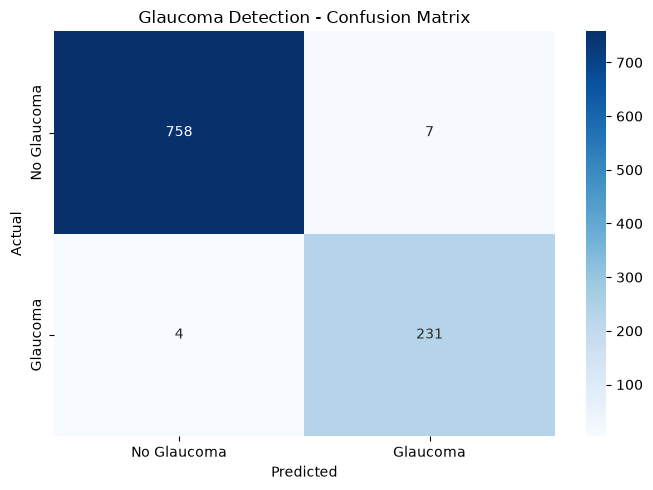


Training Accuracy:
99.83%

Testing Accuracy:
98.90%

Model saved successfully!
Model file: glaucoma_model.pkl

SAMPLE PATIENT PREDICTION

Prediction: GLAUCOMA
Probability of No Glaucoma: 0.02%
Probability of Glaucoma: 99.98%
Risk Category: High Risk

TRAINING COMPLETED

Final Test Accuracy: 98.90%

Saved files:
1. glaucoma_model.pkl
2. glaucoma_confusion_matrix.png

Glaucoma ML project completed successfully!


In [2]:
# ============================================================
# GLAUCOMA DETECTION & RISK PREDICTION
# Machine Learning Training Program
# Dataset: glaucoma_risk_dataset_5000.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

file_name = "glaucoma_risk_dataset_5000.csv"

df = pd.read_csv(file_name)

print("=" * 60)
print("GLAUCOMA ML TRAINING")
print("=" * 60)

print("\nDataset loaded successfully!")

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 records:")
print(df.head())


# ============================================================
# 2. DATASET INFORMATION
# ============================================================

print("\nDataset information:")
print(df.info())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)


# ============================================================
# 4. CHECK TARGET DISTRIBUTION
# ============================================================

print("\nGlaucoma label distribution:")
print(df["glaucoma_label"].value_counts())

print("\nGlaucoma label percentage:")
print(df["glaucoma_label"].value_counts(normalize=True) * 100)


# ============================================================
# 5. SELECT FEATURES AND TARGET
# ============================================================

# patient_id is only an identifier.
# risk_stage is an outcome/risk category, so it is not used
# as an input feature.

features = [
    "age",
    "gender",
    "iop_mmhg",
    "vertical_cdr",
    "rnfl_thickness_um",
    "visual_field_md_db",
    "family_history"
]

target = "glaucoma_label"

X = df[features]
y = df[target]


print("\nFeatures used for training:")
print(features)

print("\nTarget:")
print(target)


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 7. PREPROCESSING
# ============================================================

categorical_features = ["gender"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# ============================================================
# 8. CREATE ML MODEL
# ============================================================

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


# ============================================================
# 9. CREATE PIPELINE
# ============================================================

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ]
)


# ============================================================
# 10. TRAIN MODEL
# ============================================================

print("\nTraining model...")

pipeline.fit(X_train, y_train)

print("Training completed successfully!")


# ============================================================
# 11. MAKE PREDICTIONS
# ============================================================

y_pred = pipeline.predict(X_test)


# ============================================================
# 12. MODEL ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"\nAccuracy: {accuracy * 100:.2f}%")


# ============================================================
# 13. OTHER EVALUATION METRICS
# ============================================================

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Glaucoma", "Glaucoma"],
        zero_division=0
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Glaucoma", "Glaucoma"],
    yticklabels=["No Glaucoma", "Glaucoma"]
)

plt.title("Glaucoma Detection - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "glaucoma_confusion_matrix.png",
    dpi=300
)

plt.show()


# ============================================================
# 16. TRAINING ACCURACY VS TEST ACCURACY
# ============================================================

train_predictions = pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nTraining Accuracy:")
print(f"{train_accuracy * 100:.2f}%")

print("\nTesting Accuracy:")
print(f"{test_accuracy * 100:.2f}%")


# ============================================================
# 17. SAVE TRAINED MODEL
# ============================================================

model_file = "glaucoma_model.pkl"

joblib.dump(
    pipeline,
    model_file
)

print("\nModel saved successfully!")

print("Model file:", model_file)


# ============================================================
# 18. SAMPLE PATIENT PREDICTION
# ============================================================

sample_patient = pd.DataFrame({
    "age": [65],
    "gender": ["M"],
    "iop_mmhg": [22.5],
    "vertical_cdr": [0.65],
    "rnfl_thickness_um": [75],
    "visual_field_md_db": [-5.5],
    "family_history": [1]
})


prediction = pipeline.predict(sample_patient)

probability = pipeline.predict_proba(sample_patient)


print("\n" + "=" * 60)
print("SAMPLE PATIENT PREDICTION")
print("=" * 60)

if prediction[0] == 1:
    print("\nPrediction: GLAUCOMA")
else:
    print("\nPrediction: NO GLAUCOMA")


print(
    f"Probability of No Glaucoma: "
    f"{probability[0][0] * 100:.2f}%"
)

print(
    f"Probability of Glaucoma: "
    f"{probability[0][1] * 100:.2f}%"
)


# ============================================================
# 19. RISK STAGE
# ============================================================

if prediction[0] == 0:

    risk = "Normal"

else:

    glaucoma_probability = probability[0][1]

    if glaucoma_probability >= 0.85:
        risk = "High Risk"

    elif glaucoma_probability >= 0.60:
        risk = "Moderate Risk"

    else:
        risk = "Early / Low Risk"


print("Risk Category:", risk)


# ============================================================
# 20. FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(
    f"\nFinal Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print("\nSaved files:")
print("1. glaucoma_model.pkl")
print("2. glaucoma_confusion_matrix.png")

print("\nGlaucoma ML project completed successfully!")